In [1]:
import numpy as np
import polars as pl
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [2]:
inicial = (
    pl.scan_parquet(r"C:\Users\diogo.durao\Documents\202501_NovoBolsaFamilia.parquet")
    .rename({
        'M�S COMPET�NCIA': 'MES_COMPETENCIA',
        'M�S REFER�NCIA': 'MES_REFERENCIA',
        'C�DIGO MUNIC�PIO SIAFI': 'CODIGO_MUNICIPIO_SIAFI',
        'NOME MUNIC�PIO': 'NOME_MUNICIPIO',
    })
    .with_columns(
        pl.col("VALOR PARCELA")
        .str.replace(",", ".")   
        .cast(pl.Float64)          
    )
    .with_columns(
    pl.col("MES_REFERENCIA")
    .cast(pl.Utf8)  # Primeiro converter para string
    .str.strptime(pl.Date, "%Y%m")  # Formato YYYYMM
    .alias("DATA_REF")
)
)

display(inicial.collect())

MES_COMPETENCIA,MES_REFERENCIA,UF,CODIGO_MUNICIPIO_SIAFI,NOME_MUNICIPIO,CPF FAVORECIDO,NIS FAVORECIDO,NOME FAVORECIDO,VALOR PARCELA,DATA_REF
i64,i64,str,i64,str,str,i64,str,f64,date
202501,202308,"""SP""",7071,"""SANTOS""","""***.085.106-**""",20643890445,"""FERNANDA RAMOS TEIXEIRA""",650.0,2023-08-01
202501,202309,"""SP""",7071,"""SANTOS""","""***.085.106-**""",20643890445,"""FERNANDA RAMOS TEIXEIRA""",650.0,2023-09-01
202501,202310,"""SP""",7071,"""SANTOS""","""***.085.106-**""",20643890445,"""FERNANDA RAMOS TEIXEIRA""",650.0,2023-10-01
202501,202311,"""SP""",7071,"""SANTOS""","""***.085.106-**""",20643890445,"""FERNANDA RAMOS TEIXEIRA""",650.0,2023-11-01
202501,202312,"""SP""",7071,"""SANTOS""","""***.085.106-**""",20643890445,"""FERNANDA RAMOS TEIXEIRA""",650.0,2023-12-01
…,…,…,…,…,…,…,…,…,…
202501,202501,"""TO""",9643,"""XAMBIOA""","""""",16640890691,"""ZEIA DE SOUZA LUCIO""",750.0,2025-01-01
202501,202501,"""TO""",9643,"""XAMBIOA""","""***.273.191-**""",20644881997,"""ZENILDE ALVES DOS SANTOS""",600.0,2025-01-01
202501,202501,"""TO""",9643,"""XAMBIOA""","""""",19058661973,"""ZENOLIA RAMOS DA SILVA CARVALH…",600.0,2025-01-01


Dados para plotagem:
    DATA_REF  VALOR_MEDIO
0 2023-08-01        650.0
1 2023-09-01        650.0
2 2023-10-01        650.0
3 2023-11-01        650.0
4 2023-12-01        650.0


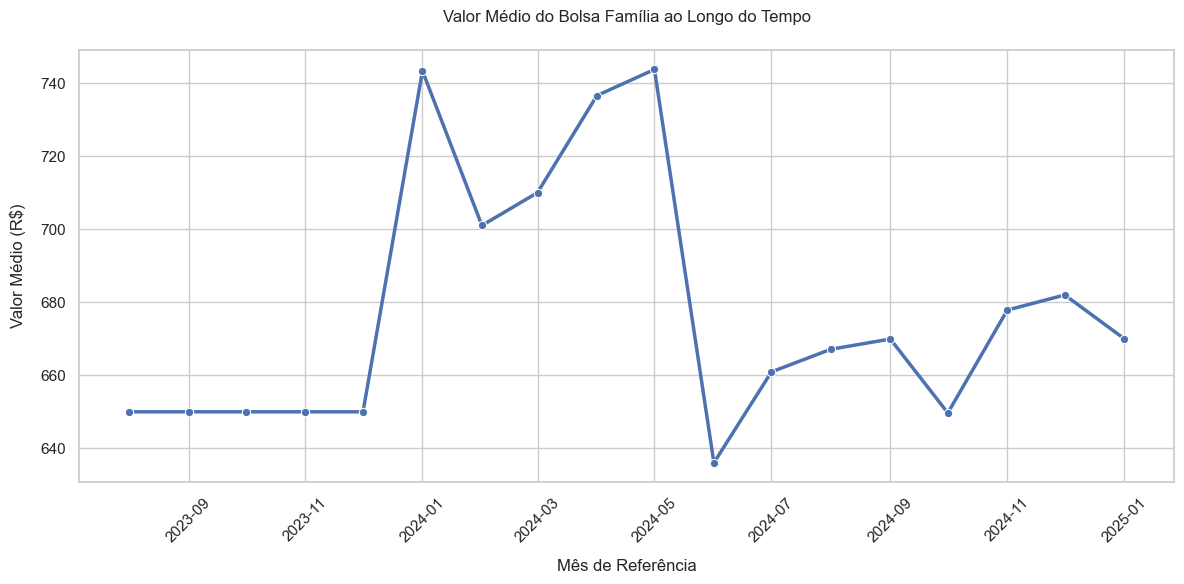

In [3]:
# Certifique-se que os dados estão corretamente agrupados
df_agrupado = inicial.group_by("DATA_REF").agg(
    pl.col("VALOR PARCELA").mean().alias("VALOR_MEDIO")
).sort("DATA_REF").collect()

# Converter para Pandas explicitamente
df_plot = df_agrupado.to_pandas()

# Verificar os dados que serão plotados
print("Dados para plotagem:")
print(df_plot.head())

# Configurar o estilo do seaborn
sns.set_theme(style="whitegrid")

# Criar a figura e o eixo explicitamente
fig, ax = plt.subplots(figsize=(12, 6))

# Plotar usando seaborn
sns.lineplot(
    data=df_plot,
    x="DATA_REF",
    y="VALOR_MEDIO",
    ax=ax,  # Especificar o eixo
    marker='o',  # Adicionar marcadores
    linewidth=2.5  # Tornar a linha mais visível
)

# Configurações adicionais
ax.set_title("Valor Médio do Bolsa Família ao Longo do Tempo", pad=20)
ax.set_xlabel("Mês de Referência", labelpad=10)
ax.set_ylabel("Valor Médio (R$)", labelpad=10)
ax.tick_params(axis='x', rotation=45)  # Rotacionar labels do eixo x

# Ajustar layout para evitar cortes
plt.tight_layout()
plt.show()

In [4]:
# 1. Converter para tipo Date do Polars se necessário
if df_agrupado["DATA_REF"].dtype != pl.Date:
    df_agrupado = df_agrupado.with_columns(
        pl.col("DATA_REF").cast(pl.Date)
    )

# 2. Calcular usando expressões puras do Polars
df_reg = df_agrupado.with_columns(
    (pl.col("DATA_REF").dt.year() * 12 + pl.col("DATA_REF").dt.month() - 
     (pl.col("DATA_REF").min().dt.year() * 12 + pl.col("DATA_REF").min().dt.month()))
    .alias("MESES_DESDE_INICIO")
)

# 3. Verificar o resultado
print(df_reg.select(["DATA_REF", "MESES_DESDE_INICIO"]).head())

shape: (5, 2)
┌────────────┬────────────────────┐
│ DATA_REF   ┆ MESES_DESDE_INICIO │
│ ---        ┆ ---                │
│ date       ┆ i32                │
╞════════════╪════════════════════╡
│ 2023-08-01 ┆ 0                  │
│ 2023-09-01 ┆ 1                  │
│ 2023-10-01 ┆ 2                  │
│ 2023-11-01 ┆ 3                  │
│ 2023-12-01 ┆ 4                  │
└────────────┴────────────────────┘


Equação da reta: VALOR_MEDIO = 0.42 * MESES_DESDE_INICIO + 674.09
Coeficiente angular (R$/mês): 0.42
Intercepto (valor inicial): R$ 674.09

Métricas de avaliação:
Coeficiente de Determinação (R²): 0.0042
Erro Quadrático Médio (MSE): 1139.90


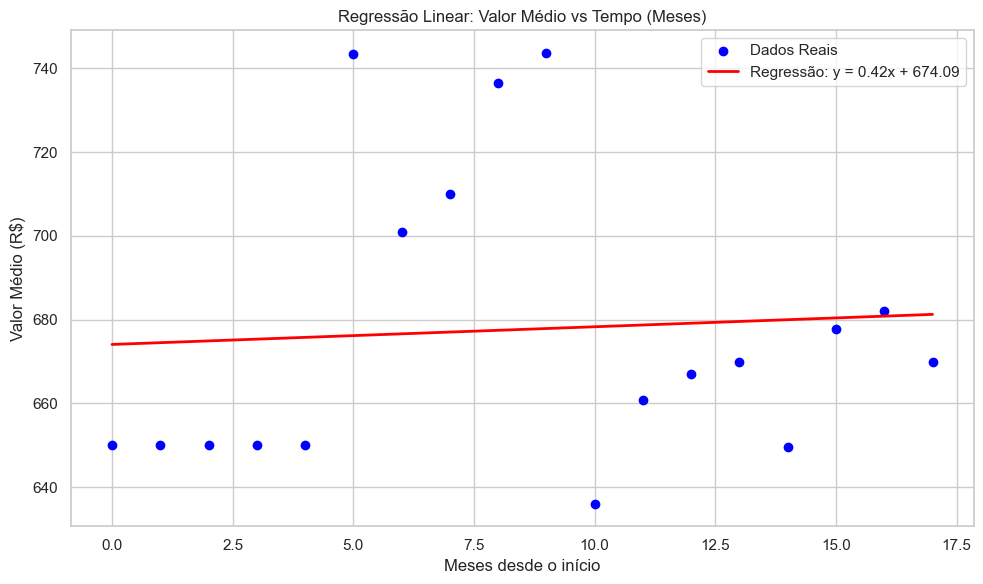

In [5]:
## 1. Preparar os dados para o modelo
# Converter para arrays numpy
X = df_reg["MESES_DESDE_INICIO"].to_numpy().reshape(-1, 1)  # Variável independente (meses)
y = df_reg["VALOR_MEDIO"].to_numpy()                        # Variável dependente (valor)

## 2. Criar e treinar o modelo
modelo = LinearRegression()
modelo.fit(X, y)

# Coeficientes do modelo
inclinacao = modelo.coef_[0]
intercepto = modelo.intercept_

print(f"Equação da reta: VALOR_MEDIO = {inclinacao:.2f} * MESES_DESDE_INICIO + {intercepto:.2f}")
print(f"Coeficiente angular (R$/mês): {inclinacao:.2f}")
print(f"Intercepto (valor inicial): R$ {intercepto:.2f}")

## 3. Fazer previsões
y_pred = modelo.predict(X)

## 4. Avaliar o modelo
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)

print(f"\nMétricas de avaliação:")
print(f"Coeficiente de Determinação (R²): {r2:.4f}")
print(f"Erro Quadrático Médio (MSE): {mse:.2f}")

## 5. Visualização dos resultados
plt.figure(figsize=(10, 6))

# Plotar dados reais
plt.scatter(X, y, color='blue', label='Dados Reais')

# Plotar linha de regressão
plt.plot(X, y_pred, color='red', linewidth=2, label=f'Regressão: y = {inclinacao:.2f}x + {intercepto:.2f}')

# Configurações do gráfico
plt.title('Regressão Linear: Valor Médio vs Tempo (Meses)')
plt.xlabel('Meses desde o início')
plt.ylabel('Valor Médio (R$)')
plt.grid(True)
plt.legend()

# Mostrar gráfico
plt.tight_layout()
plt.show()

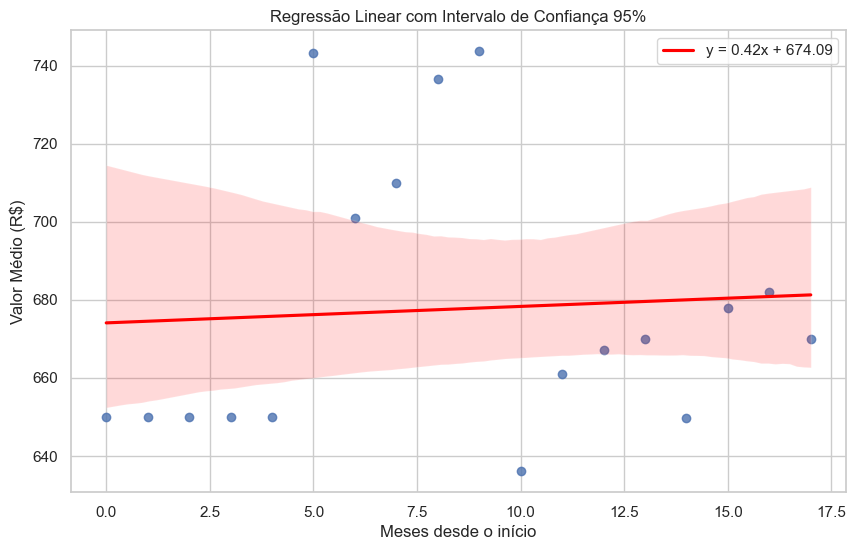

In [6]:
# Versão Alternativa com intervalo de confiança:
plt.figure(figsize=(10, 6))
sns.regplot(x=X.flatten(), y=y, ci=95, 
            line_kws={'color': 'red', 'label': f'y = {inclinacao:.2f}x + {intercepto:.2f}'})
plt.title('Regressão Linear com Intervalo de Confiança 95%')
plt.xlabel('Meses desde o início')
plt.ylabel('Valor Médio (R$)')
plt.legend()
plt.grid(True)
plt.show()